In [1]:
%pip install plotly

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 837.5 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/9.8 MB 837.5 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.8 MB 838.9 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.8 MB 898.8 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.8 MB 898.8 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.8 MB 919.0 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.8 MB 963.8 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.8 MB 976.9 kB/s eta 0:00:09
   --------- ------------------------------ 2.4/9.8 MB 1.1 MB/s eta 0:00:08
   ---------- ----------

In [8]:
# Ячейка 1: Импорт библиотек
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import cv2
from pathlib import Path
import warnings
import datetime
from typing import List, Dict, Any, Optional, Tuple
import onnxruntime as ort
import os

warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


In [9]:
# Ячейка 2: Класс TreeClassifier
class TreeClassifier:
    def __init__(
        self,
        tree_type_classifier: str,
        multi_classifier: str,
        device: str = "cpu",
        input_size: int = 320
    ):
        """
        Классификатор деревьев
        
        Args:
            tree_type_classifier: путь к ONNX модели классификации типа дерева
            multi_classifier: путь к ONNX модели мультиклассовой классификации
            device: устройство для выполнения (cpu/cuda)
            input_size: размер входного изображения
        """
        self.tree_type_classifier = ort.InferenceSession(
            tree_type_classifier, 
            providers=["CPUExecutionProvider"]
        )
        self.multi_classifier = ort.InferenceSession(
            multi_classifier, 
            providers=["CPUExecutionProvider"]
        )
        self.device = device
        self.input_size = input_size
        
        # Получаем имена входов и выходов
        self.tree_type_input_name = self.tree_type_classifier.get_inputs()[0].name
        self.multi_classifier_input_name = self.multi_classifier.get_inputs()[0].name
        
        self.tree_type_output_names = [o.name for o in self.tree_type_classifier.get_outputs()]
        self.multi_classifier_output_names = [o.name for o in self.multi_classifier.get_outputs()]
        
        print(f"Инициализирован классификатор деревьев")
        print(f"Входной размер: {input_size}x{input_size}")
        print(f"Выходы tree_type: {self.tree_type_output_names}")
        print(f"Выходы multi_classifier: {self.multi_classifier_output_names}")

    @staticmethod
    def softmax(x: np.ndarray) -> np.ndarray:
        x = np.array(x, dtype=np.float64)
        if x.ndim == 1:
            x = x - np.max(x)
            e = np.exp(x)
            return (e / e.sum()).astype(np.float32)
        else:
            x = x - np.max(x, axis=-1, keepdims=True)
            e = np.exp(x)
            return (e / e.sum(axis=-1, keepdims=True)).astype(np.float32)

    def preprocess_image(self, image: np.ndarray) -> np.ndarray:
        """
        Предобработка изображения для классификации
        """
        # Конвертируем в RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Ресайз
        image_resized = cv2.resize(
            image_rgb, 
            (self.input_size, self.input_size), 
            interpolation=cv2.INTER_LINEAR
        )
        
        # Нормализация
        image_processed = image_resized.astype(np.float32) / 255.0
        
        # Стандартная нормализация для ImageNet
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        image_processed = (image_processed - mean[None, None, :]) / std[None, None, :]
        
        # Транспонирование в формат CHW
        image_processed = np.transpose(image_processed, (2, 0, 1))
        image_processed = np.expand_dims(image_processed, axis=0)
        
        return np.ascontiguousarray(image_processed.astype(np.float32))

    def classify_single_image(self, image_path: str) -> Dict[str, Any]:
        """
        Классификация одного изображения
        """
        start_time = datetime.datetime.now()
        
        # Загрузка изображения
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Изображение не найдено: {image_path}")
            
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")
        
        # Предобработка
        processed_image = self.preprocess_image(image)
        
        try:
            # Классификация типа дерева
            tree_type_outputs = self.tree_type_classifier.run(
                None, 
                {self.tree_type_input_name: processed_image}
            )
            
            # Мультиклассовая классификация
            multi_class_outputs = self.multi_classifier.run(
                None, 
                {self.multi_classifier_input_name: processed_image}
            )
            
        except Exception as e:
            raise RuntimeError(f"Ошибка inference ONNX: {e}")
        
        # Словарь для маппинга классов
        mapping_dict = {
            'tree_type': {
                0: 'Береза', 1: 'Боярышник', 2: 'Вяз', 3: 'Дерен Белый', 4: 'Дуб',
                5: 'Ель', 6: 'Ива', 7: 'Карагана древовидная', 8: 'Кизильник', 9: 'Клен',
                10: 'Лапчатка Кустарниковая', 11: 'Лещина', 12: 'Липа', 13: 'Лиственница',
                14: 'Осина', 15: 'Пузыреплодник калинолистный', 16: 'Роза Морщинистая',
                17: 'Рябина', 18: 'Сирень Обыкновенная', 19: 'Сосна', 20: 'Спирея',
                21: 'Туя', 22: 'Чубушник', 23: 'Ясень'
            },
            'has_hollow': {0: 'No', 1: 'Yes'},
            'has_cracks': {0: 'No', 1: 'Yes'},
            'has_fruits_or_flowers': {0: 'No', 1: 'Yes'},
            'has_rot': {0: 'No', 1: 'Yes'},
            'has_trunk_damage': {0: 'No', 1: 'Yes'},
            'has_crown_damage': {0: 'No', 1: 'Yes'},
            'dry_branch_percentage': {0: 'Normal', 1: 'Dry', 2: 'Very Dry', 3: 'Extremely Dry'},
            'overall_condition': {0: '', 1: 'Аварийное', 2: 'Нездоровое', 3: 'Нормальное', 4: 'Опасное', 5: 'Хорошее'}
        }
        
        # Обработка результатов
        classification_result = {}
        
        # Обработка выхода классификации типа дерева
        for j, output_name in enumerate(self.tree_type_output_names):
            pred = tree_type_outputs[j]
            pred_vec = pred[0] if pred.ndim == 2 else pred
            class_id = int(np.argmax(pred_vec))
            confidence = float(np.max(self.softmax(pred_vec)))
            
            classification_result[output_name] = {
                "class_label": mapping_dict.get(output_name, {}).get(class_id, str(class_id)),
                "confidence": confidence,
                "class_id": class_id
            }
        
        # Обработка выхода мультиклассового классификатора
        for j, output_name in enumerate(self.multi_classifier_output_names):
            pred = multi_class_outputs[j]
            pred_vec = pred[0] if pred.ndim == 2 else pred
            class_id = int(np.argmax(pred_vec))
            confidence = float(np.max(self.softmax(pred_vec)))
            
            classification_result[output_name] = {
                "class_label": mapping_dict.get(output_name, {}).get(class_id, str(class_id)),
                "confidence": confidence,
                "class_id": class_id
            }
        
        processing_time = (datetime.datetime.now() - start_time).total_seconds()
        
        return {
            "image_path": image_path,
            "classification": classification_result,
            "processing_time_seconds": processing_time,
            "timestamp": start_time.isoformat()
        }

    def classify_batch(self, image_paths: List[str]) -> List[Dict[str, Any]]:
        """
        Классификация батча изображений
        """
        results = []
        
        for image_path in image_paths:
            try:
                result = self.classify_single_image(image_path)
                results.append(result)
                print(f"Обработано: {image_path}")
            except Exception as e:
                print(f"Ошибка при обработке {image_path}: {e}")
                continue
        
        return results

print("Класс TreeClassifier загружен успешно!")

Класс TreeClassifier загружен успешно!


In [10]:
# Ячейка 3: Тестирование классификатора на одном изображении
# Укажите пути к вашим моделям и тестовому изображению
TEST_IMAGE_PATH = r"C:\Users\shari\OneDrive\Рабочий стол\photo_2025-10-18_20-16-57.jpg"  # Замените на реальный путь
TREE_TYPE_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_tree_type_apple_vit_0.35\APPLE_XS_TRANSFORMER_TREE_TYPE_WEB_DATA.onnx"  # Замените на реальный путь
MULTI_CLASS_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_all_classes_53\simple_model.onnx"  # Замените на реальный путь

# Инициализация классификатора
try:
    classifier = TreeClassifier(
        tree_type_classifier=TREE_TYPE_MODEL,
        multi_classifier=MULTI_CLASS_MODEL,
        input_size=320,
        device="cpu"
    )
    print("Классификатор инициализирован успешно!")
    
    # Тест на одном изображении
    if os.path.exists(TEST_IMAGE_PATH):
        result = classifier.classify_single_image(TEST_IMAGE_PATH)
        print("Результат классификации одного изображения:")
        print(json.dumps(result, indent=2, ensure_ascii=False))
    else:
        print(f"Тестовое изображение не найдено: {TEST_IMAGE_PATH}")
        
except Exception as e:
    print(f"Ошибка при инициализации классификатора: {e}")

Инициализирован классификатор деревьев
Входной размер: 320x320
Выходы tree_type: ['tree_type']
Выходы multi_classifier: ['has_hollow', 'has_cracks', 'has_fruits_or_flowers', 'overall_condition', 'has_crown_damage', 'has_trunk_damage', 'has_rot']
Классификатор инициализирован успешно!
Результат классификации одного изображения:
{
  "image_path": "C:\\Users\\shari\\OneDrive\\Рабочий стол\\photo_2025-10-18_20-16-57.jpg",
  "classification": {
    "tree_type": {
      "class_label": "Осина",
      "confidence": 0.6661701202392578,
      "class_id": 14
    },
    "has_hollow": {
      "class_label": "No",
      "confidence": 0.8225024938583374,
      "class_id": 0
    },
    "has_cracks": {
      "class_label": "No",
      "confidence": 0.6340168714523315,
      "class_id": 0
    },
    "has_fruits_or_flowers": {
      "class_label": "No",
      "confidence": 0.8151186108589172,
      "class_id": 0
    },
    "overall_condition": {
      "class_label": "Нормальное",
      "confidence": 0.38

In [ ]:
# Ячейка 4: Класс TreeClassificationAnalyzer
class TreeClassificationAnalyzer:
    def __init__(self, classifier: TreeClassifier):
        """
        Анализатор результатов классификации деревьев
        
        Args:
            classifier: инициализированный классификатор деревьев
        """
        self.classifier = classifier
        self.results_df = None
        self.predictions = []
        self.true_labels = []
        
    def load_and_process_dataset(self, json_path: str) -> pd.DataFrame:
        """
        Загрузка и обработка датасета из JSON
        
        Args:
            json_path: путь к JSON файлу с данными
            
        Returns:
            DataFrame с результатами
        """
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Извлекаем пути к изображениям и истинные метки
        image_paths = []
        true_labels = []
        
        for item in data:
            if 'image' in item and 'tree_type' in item:
                image_paths.append(item['image'])
                true_labels.append(item['tree_type'])
        
        print(f"Загружено {len(image_paths)} изображений для классификации")
        
        # Запускаем классификацию
        self.predictions = self.classifier.classify_batch(image_paths)
        self.true_labels = true_labels
        
        # Создаем DataFrame с результатами
        results_data = []
        for i, pred in enumerate(self.predictions):
            if i < len(self.true_labels):
                true_label = self.true_labels[i]
                pred_label = pred['classification']['tree_type']['class_label']
                confidence = pred['classification']['tree_type']['confidence']
                
                results_data.append({
                    'image_path': pred['image_path'],
                    'true_label': true_label,
                    'predicted_label': pred_label,
                    'confidence': confidence,
                    'is_correct': true_label == pred_label,
                    'processing_time': pred['processing_time_seconds']
                })
        
        self.results_df = pd.DataFrame(results_data)
        print(f"Создан DataFrame с {len(self.results_df)} записями")
        return self.results_df
    
    

print("Класс TreeClassificationAnalyzer загружен успешно!")

Класс TreeClassificationAnalyzer загружен успешно!


In [19]:
# Ячейка 5: Методы визуализации анализатора
# Добавляем методы к классу TreeClassificationAnalyzer

def _plot_overall_accuracy(self):
    """Визуализация общей точности"""
    accuracy = accuracy_score(self.results_df['true_label'], self.results_df['predicted_label'])
    total_images = len(self.results_df)
    
    plt.figure(figsize=(8, 6))
    plt.pie([accuracy, 1-accuracy], 
            labels=[f'Правильные\n{accuracy:.1%}', f'Ошибки\n{1-accuracy:.1%}'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
    plt.title(f'Общая точность классификации\n({total_images} изображений)')
    plt.show()

def _plot_confusion_matrix(self):
    """Матрица ошибок"""
    cm = confusion_matrix(self.results_df['true_label'], self.results_df['predicted_label'])
    classes = sorted(self.results_df['true_label'].unique())
    
    # Нормализация
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
               xticklabels=classes, yticklabels=classes)
    plt.title('Матрица ошибок (нормализованная)')
    plt.xlabel('Предсказанные классы')
    plt.ylabel('Истинные классы')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def _plot_class_accuracy(self):
    """Точность по классам"""
    class_accuracy = self.results_df.groupby('true_label').apply(
        lambda x: (x['true_label'] == x['predicted_label']).mean()
    ).sort_values()
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(class_accuracy)), class_accuracy.values, color='skyblue')
    plt.yticks(range(len(class_accuracy)), class_accuracy.index)
    plt.xlabel('Точность')
    plt.title('Точность по классам деревьев')
    plt.grid(axis='x', alpha=0.3)
    
    # Добавление значений на столбцы
    for i, acc in enumerate(class_accuracy.values):
        plt.text(acc + 0.01, i, f'{acc:.1%}', va='center')
    
    plt.tight_layout()
    plt.show()

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_overall_accuracy = _plot_overall_accuracy
TreeClassificationAnalyzer._plot_confusion_matrix = _plot_confusion_matrix
TreeClassificationAnalyzer._plot_class_accuracy = _plot_class_accuracy

print("Методы визуализации добавлены успешно!")

Методы визуализации добавлены успешно!


In [13]:
# Ячейка 6: Дополнительные методы визуализации
def _plot_confidence_distribution(self):
    """Распределение уверенности модели"""
    plt.figure(figsize=(10, 6))
    plt.hist(self.results_df['confidence'], bins=20, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Уверенность модели')
    plt.ylabel('Количество изображений')
    plt.title('Распределение уверенности модели')
    plt.grid(alpha=0.3)
    
    mean_confidence = self.results_df['confidence'].mean()
    plt.axvline(mean_confidence, color='red', linestyle='--', 
               label=f'Среднее: {mean_confidence:.3f}')
    plt.legend()
    plt.show()

def _plot_class_distribution(self):
    """Сравнение распределения классов в данных"""
    true_dist = Counter(self.results_df['true_label'])
    pred_dist = Counter(self.results_df['predicted_label'])
    
    all_classes = sorted(set(list(true_dist.keys()) + list(pred_dist.keys())))
    true_counts = [true_dist.get(cls, 0) for cls in all_classes]
    pred_counts = [pred_dist.get(cls, 0) for cls in all_classes]
    
    x = np.arange(len(all_classes))
    width = 0.35
    
    plt.figure(figsize=(15, 8))
    plt.bar(x - width/2, true_counts, width, label='Истинное', alpha=0.7)
    plt.bar(x + width/2, pred_counts, width, label='Предсказанное', alpha=0.7)
    
    plt.xlabel('Классы деревьев')
    plt.ylabel('Количество')
    plt.title('Распределение классов')
    plt.xticks(x, all_classes, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def _plot_processing_time(self):
    """Распределение времени обработки"""
    plt.figure(figsize=(10, 6))
    plt.hist(self.results_df['processing_time'], bins=20, alpha=0.7, color='green', edgecolor='black')
    plt.xlabel('Время обработки (секунды)')
    plt.ylabel('Количество изображений')
    plt.title('Распределение времени обработки')
    plt.grid(alpha=0.3)
    
    mean_time = self.results_df['processing_time'].mean()
    plt.axvline(mean_time, color='red', linestyle='--', 
               label=f'Среднее: {mean_time:.3f}с')
    plt.legend()
    plt.show()

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_confidence_distribution = _plot_confidence_distribution
TreeClassificationAnalyzer._plot_class_distribution = _plot_class_distribution
TreeClassificationAnalyzer._plot_processing_time = _plot_processing_time

print("Дополнительные методы визуализации добавлены успешно!")

Дополнительные методы визуализации добавлены успешно!


In [14]:
# Ячейка 7: Методы анализа ошибок и отчетов
def _plot_top_errors(self):
    """Анализ самых частых ошибок"""
    errors = self.results_df[self.results_df['true_label'] != self.results_df['predicted_label']]
    
    if errors.empty:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, 'Нет ошибок для анализа!', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Топ ошибок')
        plt.show()
        return
    
    error_pairs = errors.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
    top_errors = error_pairs.nlargest(8, 'count')
    
    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(top_errors)), top_errors['count'])
    plt.yticks(range(len(top_errors)), 
              [f"{row['true_label']} → {row['predicted_label']}" for _, row in top_errors.iterrows()])
    plt.xlabel('Количество ошибок')
    plt.title('Топ-8 самых частых ошибок')
    plt.grid(axis='x', alpha=0.3)
    
    for bar, count in zip(bars, top_errors['count']):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{count}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()

def generate_detailed_report(self) -> Dict[str, Any]:
    """Генерация детального текстового отчета"""
    if self.results_df is None:
        return {"error": "Данные не загружены"}
    
    accuracy = accuracy_score(self.results_df['true_label'], self.results_df['predicted_label'])
    total_images = len(self.results_df)
    unique_classes = len(self.results_df['true_label'].unique())
    
    # Метрики по классам
    class_report = classification_report(self.results_df['true_label'], 
                                       self.results_df['predicted_label'], 
                                       output_dict=True)
    
    # Анализ уверенности
    mean_confidence = self.results_df['confidence'].mean()
    mean_confidence_correct = self.results_df[self.results_df['is_correct']]['confidence'].mean()
    mean_confidence_incorrect = self.results_df[~self.results_df['is_correct']]['confidence'].mean() if not self.results_df[~self.results_df['is_correct']].empty else 0
    
    # Топ классов по точности
    class_accuracy = self.results_df.groupby('true_label').apply(
        lambda x: (x['true_label'] == x['predicted_label']).mean()
    ).sort_values(ascending=False)
    
    report = {
        "overall_metrics": {
            "accuracy": accuracy,
            "total_images": total_images,
            "unique_classes": unique_classes,
            "error_count": len(self.results_df[~self.results_df['is_correct']]),
            "mean_processing_time": self.results_df['processing_time'].mean(),
            "mean_confidence": mean_confidence
        },
        "confidence_analysis": {
            "mean_confidence_correct": mean_confidence_correct,
            "mean_confidence_incorrect": mean_confidence_incorrect,
            "confidence_difference": mean_confidence_correct - mean_confidence_incorrect
        },
        "top_performing_classes": class_accuracy.head(5).to_dict(),
        "worst_performing_classes": class_accuracy.tail(5).to_dict(),
        "detailed_class_report": class_report
    }
    
    # Вывод отчета в консоль
    print("=" * 60)
    print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ДЕРЕВЬЕВ")
    print("=" * 60)
    print(f"Общая точность: {accuracy:.2%}")
    print(f"Обработано изображений: {total_images}")
    print(f"Уникальных классов: {unique_classes}")
    print(f"Количество ошибок: {report['overall_metrics']['error_count']}")
    print(f"Среднее время обработки: {report['overall_metrics']['mean_processing_time']:.3f} сек")
    print(f"Средняя уверенность: {mean_confidence:.3f}")
    print(f"Средняя уверенность (правильные): {mean_confidence_correct:.3f}")
    print(f"Средняя уверенность (ошибки): {mean_confidence_incorrect:.3f}")
    
    print("\nТоп-5 самых точных классов:")
    for class_name, acc in class_accuracy.head().items():
        print(f"  {class_name}: {acc:.2%}")
    
    print("\nТоп-5 самых проблемных классов:")
    for class_name, acc in class_accuracy.tail().items():
        print(f"  {class_name}: {acc:.2%}")
    
    return report

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_top_errors = _plot_top_errors
TreeClassificationAnalyzer.generate_detailed_report = generate_detailed_report

print("Методы анализа ошибок и отчетов добавлены успешно!")

Методы анализа ошибок и отчетов добавлены успешно!


In [15]:
# Ячейка 8: Комплексная визуализация
def create_comprehensive_dashboard(self):
    """Создание комплексной визуализации всех метрик"""
    if self.results_df is None:
        print("Сначала загрузите данные с помощью load_and_process_dataset()")
        return
    
    print("Создание комплексной визуализации...")
    
    # 1. Общая точность
    print("\n1. Общая точность классификации:")
    self._plot_overall_accuracy()
    
    # 2. Матрица ошибок
    print("\n2. Матрица ошибок:")
    self._plot_confusion_matrix()
    
    # 3. Точность по классам
    print("\n3. Точность по классам:")
    self._plot_class_accuracy()
    
    # 4. Распределение уверенности
    print("\n4. Распределение уверенности:")
    self._plot_confidence_distribution()
    
    # 5. Сравнение распределения классов
    print("\n5. Распределение классов:")
    self._plot_class_distribution()
    
    # 6. Время обработки
    print("\n6. Время обработки:")
    self._plot_processing_time()
    
    # 7. Топ ошибок
    print("\n7. Топ ошибок:")
    self._plot_top_errors()
    
    print("\nВизуализация завершена!")

# Добавляем метод к классу
TreeClassificationAnalyzer.create_comprehensive_dashboard = create_comprehensive_dashboard

print("Метод комплексной визуализации добавлен успешно!")

Метод комплексной визуализации добавлен успешно!


In [16]:
# Ячейка 9: Полный пример использования
def main():
    """
    Полный пример использования классификатора и анализатора
    """
    # Конфигурация
    JSON_DATASET_PATH = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\NEW_DATA_VAL.json"  # Замените на реальный путь
    TREE_TYPE_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_tree_type_apple_vit_0.35\APPLE_XS_TRANSFORMER_TREE_TYPE_WEB_DATA.onnx"  # Замените на реальный путь
    MULTI_CLASS_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_all_classes_53\simple_model.onnx"  # Замените на реальный путь
    
    try:
        # 1. Инициализация классификатора
        print("🚀 Инициализация классификатора...")
        classifier = TreeClassifier(
            tree_type_classifier=TREE_TYPE_MODEL,
            multi_classifier=MULTI_CLASS_MODEL,
            input_size=320,
            device="cpu"
        )
        
        # 2. Инициализация анализатора
        print("📊 Инициализация анализатора...")
        analyzer = TreeClassificationAnalyzer(classifier)
        
        # 3. Загрузка и обработка данных
        print("📁 Загрузка датасета...")
        results_df = analyzer.load_and_process_dataset(JSON_DATASET_PATH)
        
        # 4. Просмотр первых результатов
        print("\n📋 Первые 5 результатов:")
        print(results_df.head())
        
        # 5. Создание визуализаций
        print("\n📈 Создание визуализаций...")
        analyzer.create_comprehensive_dashboard()
        
        # 6. Генерация отчета
        print("\n📄 Генерация детального отчета...")
        report = analyzer.generate_detailed_report()
        
        return analyzer, report
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None, None

print("Функция main() готова к использованию!")

Функция main() готова к использованию!


🚀 Инициализация классификатора...
Инициализирован классификатор деревьев
Входной размер: 320x320
Выходы tree_type: ['tree_type']
Выходы multi_classifier: ['has_hollow', 'has_cracks', 'has_fruits_or_flowers', 'overall_condition', 'has_crown_damage', 'has_trunk_damage', 'has_rot']
📊 Инициализация анализатора...
📁 Загрузка датасета...
Загружено 449 изображений для классификации
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Лиственница\Снимок экрана 2025-10-16 195234.png
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Ель\Снимок экрана 2025-10-17 223558.png
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Сосна\Снимок экрана 2025-10-17 210358.png
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Боярышник\000044.jpg
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Рябина\Снимок экрана 2025-10-17 212014.png
Обработано: C:\Users\shari\PycharmProjects\MegaDendrologAI\new_data\Сирень Обыкновенная\

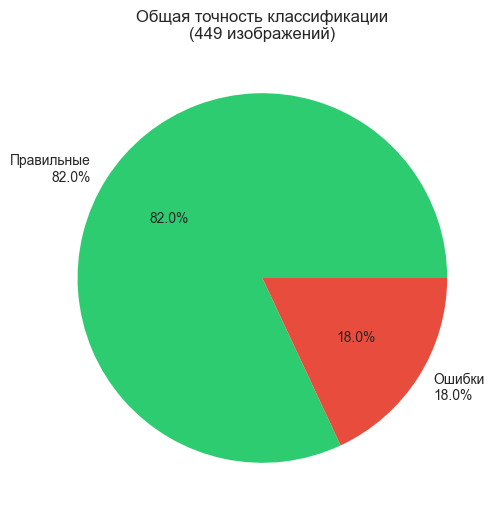


2. Матрица ошибок:


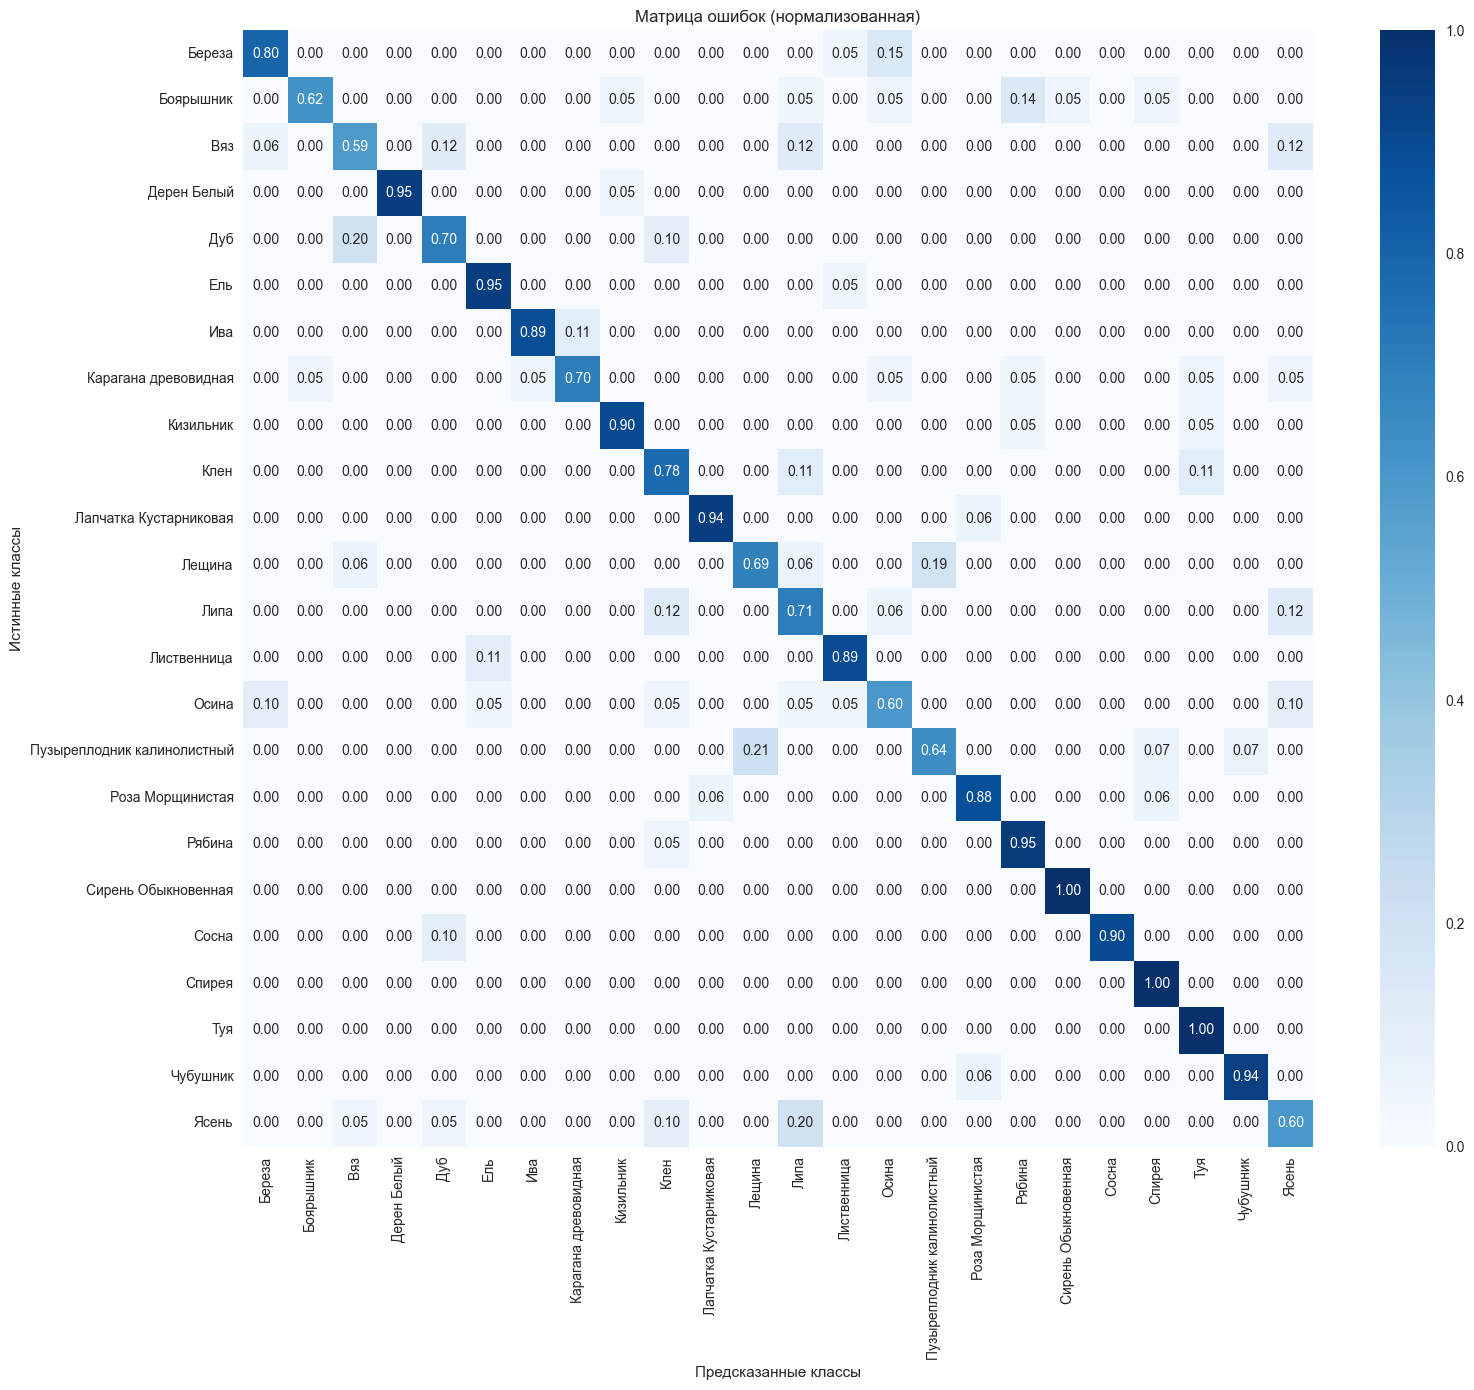


3. Точность по классам:


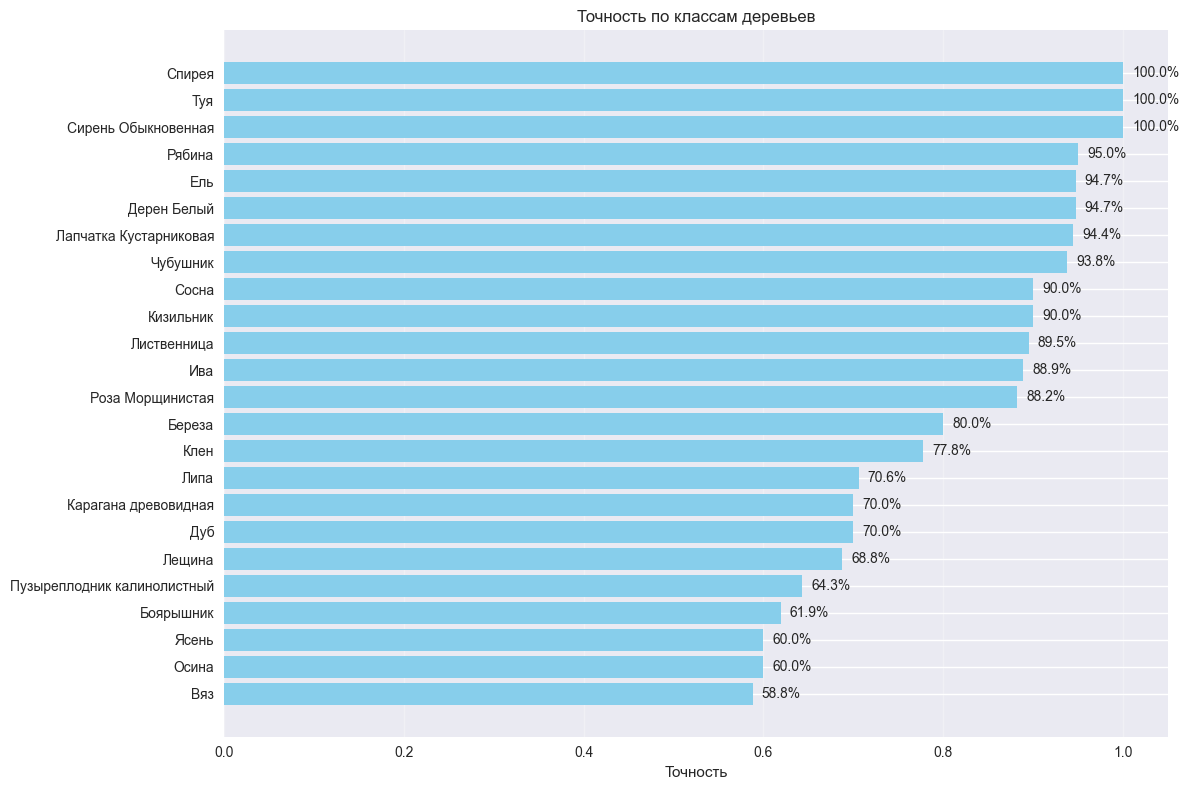


4. Распределение уверенности:


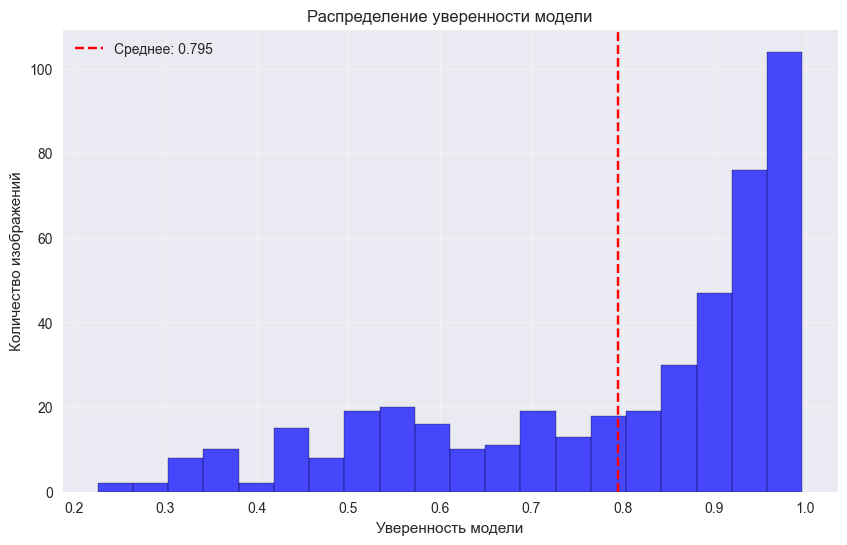


5. Распределение классов:


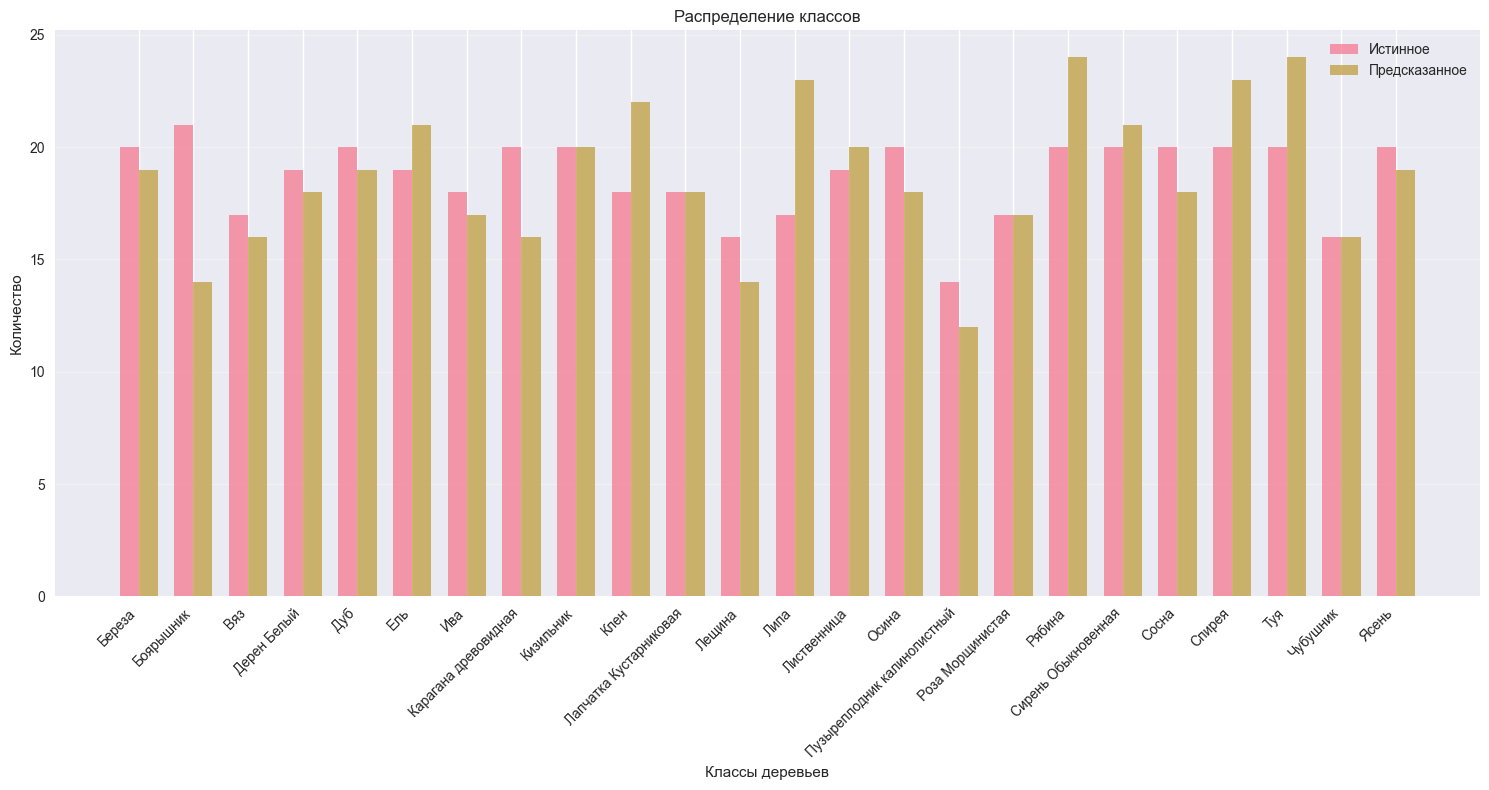


6. Время обработки:


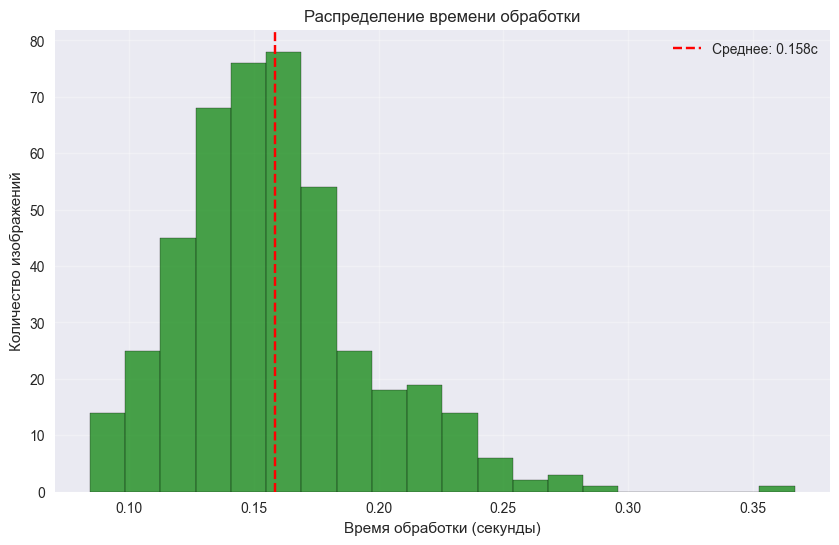


7. Топ ошибок:


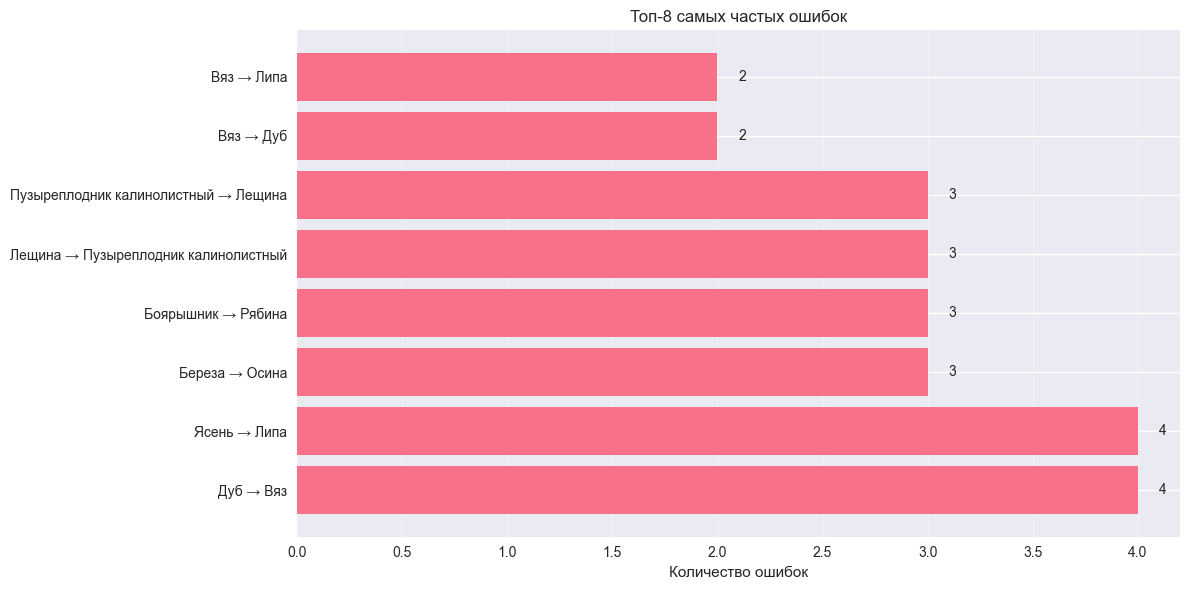


Визуализация завершена!

📄 Генерация детального отчета...
ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ДЕРЕВЬЕВ
Общая точность: 81.96%
Обработано изображений: 449
Уникальных классов: 24
Количество ошибок: 81
Среднее время обработки: 0.158 сек
Средняя уверенность: 0.795
Средняя уверенность (правильные): 0.847
Средняя уверенность (ошибки): 0.559

Топ-5 самых точных классов:
  Туя: 100.00%
  Сирень Обыкновенная: 100.00%
  Спирея: 100.00%
  Рябина: 95.00%
  Дерен Белый: 94.74%

Топ-5 самых проблемных классов:
  Пузыреплодник калинолистный: 64.29%
  Боярышник: 61.90%
  Осина: 60.00%
  Ясень: 60.00%
  Вяз: 58.82%
✅ Анализ завершен успешно!


In [20]:
analyzer, report = main()

if analyzer is not None:
    print("✅ Анализ завершен успешно!")
else:
    print("❌ Анализ завершен с ошибками")

In [18]:
def analyze_model_performance(analyzer: TreeClassificationAnalyzer):
    """
    Анализ производительности модели
    """
    if analyzer.results_df is None:
        print("Сначала загрузите данные!")
        return
    
    df = analyzer.results_df
    
    print("📈 Анализ производительности модели:")
    print(f"  - Средняя уверенность: {df['confidence'].mean():.3f}")
    print(f"  - Медианная уверенность: {df['confidence'].median():.3f}")
    print(f"  - Стандартное отклонение уверенности: {df['confidence'].std():.3f}")
    print(f"  - Минимальная уверенность: {df['confidence'].min():.3f}")
    print(f"  - Максимальная уверенность: {df['confidence'].max():.3f}")
    
    print(f"\n⏱️ Временные метрики:")
    print(f"  - Среднее время обработки: {df['processing_time'].mean():.3f} сек")
    print(f"  - Общее время обработки: {df['processing_time'].sum():.3f} сек")
    
    # Анализ корреляции между уверенностью и правильностью
    correlation = df[['confidence', 'is_correct']].corr().iloc[0, 1]
    print(f"\n📊 Корреляция уверенность-правильность: {correlation:.3f}")

print("Дополнительные утилиты для отладки загружены!")

Дополнительные утилиты для отладки загружены!
